# ScienceQA Vision Challenge — **Training Notebook**

Fine-tunes `HuggingFaceTB/SmolVLM-500M-Instruct` on the ScienceQA visual MCQ task with **QLoRA / LoRA**, then saves a LoRA adapter that the companion `infer.ipynb` loads to generate `submission.csv`.

## Strategy (why this should beat a naive baseline)

1. **Multiple-choice log-likelihood scoring** instead of free-form generation. We score each candidate letter (`A`, `B`, …) and pick the highest. Generation with a 500M model produces verbose / wrong tokens; scoring is deterministic and a strict superset of the supervised signal.
2. **QLoRA** — base model in 4-bit NF4, trainable LoRA adapters on attention projections only. We confirm `trainable_params < 5 M` programmatically.
3. **Choice-shuffle augmentation** — at training time we randomly permute the `choices` list and re-target the answer letter. This destroys positional bias (`A` is the right answer 35 % of the time in train) and forces the model to *read* the options.
4. **Lecture/hint-aware prompting** — we use SmolVLM's chat template and inject `lecture` + `hint` only when present and short enough to fit, with a hard cap so prompts don't blow up the KV cache.
5. **Per-subject monitoring** — validation accuracy is broken down by `subject` and `grade` so you know where to spend the next training hour.
6. **bf16 mixed precision** + cosine LR + warmup + gradient accumulation. A100 likes bf16 a lot more than fp16.

## Constraints we respect

- `SmolVLM-500M-Instruct` is the only allowed checkpoint.
- ≤ 5 M trainable parameters (asserted in the LoRA cell).
- Only the provided competition data is used — no external scraped data.
- Inference runs offline (the `infer.ipynb` does not call out to the network).

> **Run order:** execute cells top-to-bottom. The training loop saves the LoRA adapter to `OUT_DIR/adapter` — point `infer.ipynb` at that path.


## 0. Install dependencies

Pinned versions matching the starter so the chat template and processor behave the same as the course baseline.

In [1]:
# Run once per Colab VM. Comment out if already installed.
%pip install -q transformers==4.57.6 peft==0.18.1 bitsandbytes==0.44.1 accelerate==1.0.1 datasets pillow matplotlib seaborn bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 152.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.4/122.4 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.9/330.9 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 55.9 MB/s eta 0:00:00


In [2]:
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.2 MB/s eta 0:00:00
  Attempting uninstall: bitsandbytes
    Found existing installation: bitsandbytes 0.44.1
    Uninstalling bitsandbytes-0.44.1:
      Successfully uninstalled bitsandbytes-0.44.1


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports & configuration

All hyper-parameters live in the `CFG` dataclass — change once, propagates everywhere.

In [5]:
@dataclass
class CFG:
    # ── Paths ────────────────────────────────────────────────────────────
    data_dir: Path = Path("data")                 # contains train.csv, val.csv, test.csv, images/
    out_dir : Path = Path("outputs_train")        # adapter + plots get saved here
    adapter_dir: Path = Path("outputs_train/adapter")  # final LoRA adapter

    # ── Model ────────────────────────────────────────────────────────────
    model_id: str = "HuggingFaceTB/SmolVLM-500M-Instruct"
    img_size: int = 384                           # SmolVLM tile size; 384 keeps diagram detail
    use_4bit: bool = False                        # A100 has VRAM; bf16 LoRA trains faster & cleaner
    bf16    : bool = True

    # ── LoRA ─────────────────────────────────────────────────────────────
    lora_r       : int = 16
    lora_alpha   : int = 32
    lora_dropout : float = 0.05
    # Attention-only LoRA on the language model. Vision tower is frozen.
    lora_target_modules: tuple = ("q_proj", "k_proj", "v_proj", "o_proj")

    # ── Optim ────────────────────────────────────────────────────────────
    epochs        : int   = 3
    micro_bsz     : int   = 4         # per-step batch
    grad_accum    : int   = 4         # effective batch = 16
    eval_bsz      : int   = 8
    lr            : float = 1e-4
    weight_decay  : float = 0.0
    warmup_ratio  : float = 0.05
    max_grad_norm : float = 1.0

    # ── Prompt ───────────────────────────────────────────────────────────
    max_context_chars: int = 1200     # truncate long lectures+hints
    use_lecture: bool = True
    use_hint   : bool = True
    shuffle_choices_train: bool = True

    # ── Eval / logging ───────────────────────────────────────────────────
    log_every  : int = 25
    eval_every : int = 250            # steps; also evaluates at end of each epoch
    eval_max_samples: int = 600       # cap mid-training eval for speed; full eval at end
    save_best  : bool = True

cfg = CFG()
cfg.out_dir.mkdir(parents=True, exist_ok=True)
cfg.adapter_dir.mkdir(parents=True, exist_ok=True)
print(json.dumps({k: str(v) for k, v in cfg.__dict__.items()}, indent=2))

{
  "data_dir": "data",
  "out_dir": "outputs_train",
  "adapter_dir": "outputs_train/adapter",
  "model_id": "HuggingFaceTB/SmolVLM-500M-Instruct",
  "img_size": "384",
  "use_4bit": "False",
  "bf16": "True",
  "lora_r": "16",
  "lora_alpha": "32",
  "lora_dropout": "0.05",
  "lora_target_modules": "('q_proj', 'k_proj', 'v_proj', 'o_proj')",
  "epochs": "3",
  "micro_bsz": "4",
  "grad_accum": "4",
  "eval_bsz": "8",
  "lr": "0.0001",
  "weight_decay": "0.0",
  "warmup_ratio": "0.05",
  "max_grad_norm": "1.0",
  "max_context_chars": "1200",
  "use_lecture": "True",
  "use_hint": "True",
  "shuffle_choices_train": "True",
  "log_every": "25",
  "eval_every": "250",
  "eval_max_samples": "600",
  "save_best": "True"
}


## 2. Mount Drive / locate the data (Colab)

If your competition data lives in Drive, uncomment the mount cell. Otherwise edit `cfg.data_dir` to point at the unzipped folder.

In [10]:
# cfg.data_dir = Path('/content/drive/MyDrive/scienceqa')   # <-- edit me
cfg.out_dir  = Path('/content/drive/MyDrive/scienceqa/outputs_train')
cfg.adapter_dir = cfg.out_dir / 'adapter'
cfg.out_dir.mkdir(parents=True, exist_ok=True)
cfg.adapter_dir.mkdir(parents=True, exist_ok=True)

assert (cfg.data_dir / "train.csv").exists(), f"train.csv not found under {cfg.data_dir}"
assert (cfg.data_dir / "val.csv").exists(),   f"val.csv not found under {cfg.data_dir}"
assert (cfg.data_dir / "test.csv").exists(),  f"test.csv not found under {cfg.data_dir}"
print("data ok ->", cfg.data_dir.resolve())

data ok -> /content/data


In [11]:
import os

# 1. Define paths
# UPDATE THIS to match where the 'images' folder is in your Google Drive
drive_images_path = '/content/drive/MyDrive/images'

local_data_dir = '/content/data'
local_images_path = '/content/data/images'

# Ensure the local data directory exists (where the CSVs should be)
os.makedirs(local_data_dir, exist_ok=True)

# 2. Copy images to local Colab storage for faster training I/O
if not os.path.exists(local_images_path):
    print(f"Copying images from {drive_images_path} to {local_images_path}...")
    print("This might take a few minutes depending on the size, but drastically speeds up training.")
    !cp -r "{drive_images_path}" "{local_data_dir}/"
    print("Copy complete! ✅")
else:
    print("Images already exist locally! ✅")


Copying images from /content/drive/MyDrive/images to /content/data/images...
This might take a few minutes depending on the size, but drastically speeds up training.
Copy complete! ✅


## 3. Load CSVs

In [12]:
train_df = pd.read_csv(cfg.data_dir / "train.csv")
val_df   = pd.read_csv(cfg.data_dir / "val.csv")
test_df  = pd.read_csv(cfg.data_dir / "test.csv")

for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(json.loads)

print(f"train: {len(train_df):,} | val: {len(val_df):,} | test: {len(test_df):,}")
train_df.head(2)

train: 3,109 | val: 1,048 | test: 1,008


,id,image_path,question,choices,num_choices,answer,hint,lecture,solution,task,grade,subject,topic,category,skill
0,train_07667,images/train/train_07667.png,Why might putting each tadpole in its own pool...,[the male's tadpoles will be larger when they ...,3,2,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...
1,train_02628,images/train/train_02628.png,Why might forming strong social bonds with oth...,"[the female's offspring will live longer, the ...",3,0,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...


## 4. EDA — what does the data look like?

We want to confirm:

- How biased is the answer position? (If `A` is right 40 % of the time, models that always pick `A` get 40 % accuracy — choice-shuffle augmentation is critical.)
- Distribution of `num_choices` so we know how many letter tokens we need.
- Subject / grade balance so we know what we'll be optimising for.

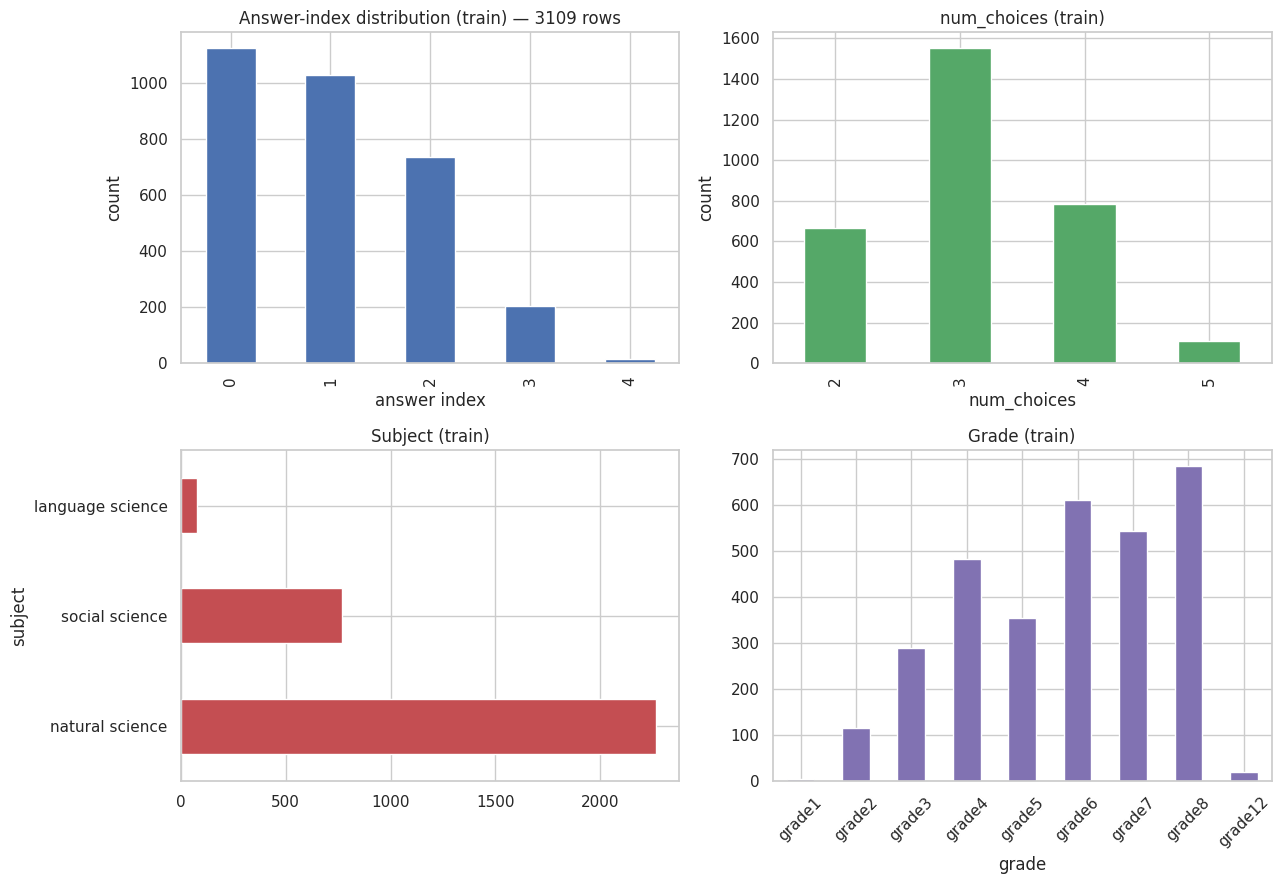


Most common num_choices : 3
Max num_choices         : 5
Always-pick-0 baseline  : 36.15 %
Always-pick-mode baseline (val): 33.11 %


In [13]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) answer-position bias on train
ax = axes[0, 0]
train_df["answer"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title(f"Answer-index distribution (train) — {len(train_df)} rows")
ax.set_xlabel("answer index"); ax.set_ylabel("count")

# (b) num_choices
ax = axes[0, 1]
train_df["num_choices"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("num_choices (train)")
ax.set_xlabel("num_choices"); ax.set_ylabel("count")

# (c) subject distribution
ax = axes[1, 0]
train_df["subject"].value_counts().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_title("Subject (train)")

# (d) grade
ax = axes[1, 1]
gorder = sorted(train_df["grade"].dropna().unique(), key=lambda g: int("".join(c for c in g if c.isdigit()) or 0))
train_df["grade"].value_counts().reindex(gorder).plot(kind="bar", ax=ax, color="#8172B2")
ax.set_title("Grade (train)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(cfg.out_dir / "eda_overview.png", dpi=120)
plt.show()

print("\nMost common num_choices :", train_df["num_choices"].mode().iloc[0])
print("Max num_choices         :", train_df["num_choices"].max())
print("Always-pick-0 baseline  :", round((train_df["answer"] == 0).mean() * 100, 2), "%")
print("Always-pick-mode baseline (val):",
      round(((val_df["answer"] == train_df["answer"].mode().iloc[0])).mean() * 100, 2), "%")

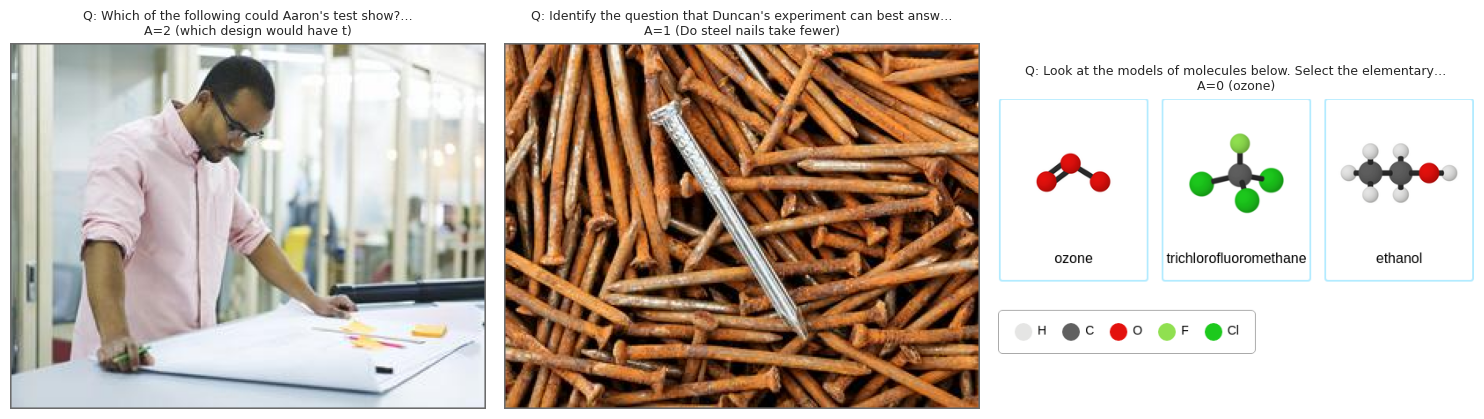

In [14]:
# Visual inspection: show 3 random examples (image + question)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, idx in zip(axes, train_df.sample(3, random_state=SEED).index):
    row = train_df.loc[idx]
    img = Image.open(cfg.data_dir / row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"Q: {row['question'][:60]}…\nA={row['answer']} ({row['choices'][row['answer']][:25]})", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Prompt engineering

We use SmolVLM's chat template via `processor.apply_chat_template`. The assistant turn contains *just the answer letter* — that's the only token we score / supervise.

**Why a single letter?**  Multi-token answers create label-leak risk through teacher forcing and waste capacity. The leaderboard metric is single-letter accuracy.

In [15]:
CHOICE_LETTERS = "ABCDEFGHIJ"

def _truncate(s: str, n: int) -> str:
    s = str(s).strip()
    return s if len(s) <= n else s[: n - 1] + "…"

def build_user_text(row, max_ctx: int = 1200, use_lecture=True, use_hint=True,
                    choices: Optional[List[str]] = None) -> str:
    """User-turn text. Image is attached separately by the processor."""
    if choices is None:
        choices = row["choices"]

    parts = []
    if use_lecture:
        lec = row.get("lecture", None)
        if isinstance(lec, str) and lec.strip():
            parts.append(_truncate(lec, max_ctx))
    if use_hint:
        hint = row.get("hint", None)
        if isinstance(hint, str) and hint.strip():
            parts.append(_truncate(hint, max_ctx // 2))
    context = "\n".join(parts)

    choice_lines = "\n".join(f"{CHOICE_LETTERS[i]}. {c}" for i, c in enumerate(choices))

    text  = ""
    if context:
        text += f"Context:\n{context}\n\n"
    text += f"Question: {row['question']}\n\n"
    text += f"Choices:\n{choice_lines}\n\n"
    text += "Answer with a single letter only."
    return text


def build_messages(row, *, include_answer: bool, choices=None, answer_idx=None):
    user_text = build_user_text(
        row,
        max_ctx=cfg.max_context_chars,
        use_lecture=cfg.use_lecture,
        use_hint=cfg.use_hint,
        choices=choices,
    )
    msgs = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": user_text},
        ]}
    ]
    if include_answer:
        idx = answer_idx if answer_idx is not None else int(row["answer"])
        msgs.append({"role": "assistant", "content": [
            {"type": "text", "text": CHOICE_LETTERS[idx]},
        ]})
    return msgs


# Quick sanity print
sample = train_df.iloc[0]
for m in build_messages(sample, include_answer=True):
    print(m["role"].upper(), "→", m["content"][-1]["text"][:200], "..." if len(m["content"][-1]["text"]) > 200 else "")

USER → Context:
Animals increase their reproductive success when they have offspring that survive to reproduce.
Animals can increase their chances of having offspring by behaving in ways that help them get p ...
ASSISTANT → C 


## 6. Dataset class

Important detail: at *train* time we optionally permute `choices`. We compute the new answer index after permutation and rebuild the prompt with the new order. The model then has to actually look at the option text to know which letter is correct.

In [16]:
class ScienceQADataset(Dataset):
    def __init__(self, df: pd.DataFrame, data_dir: Path, *,
                 img_size: int = 384, is_train: bool = False, shuffle_choices: bool = False):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.img_size = img_size
        self.is_train = is_train
        self.shuffle_choices = shuffle_choices

    def __len__(self):
        return len(self.df)

    def _load_image(self, rel_path):
        img = Image.open(self.data_dir / rel_path).convert("RGB")
        # Long-side resize keeps aspect ratio (better for diagrams)
        w, h = img.size
        s = self.img_size / max(w, h)
        if s < 1.0:
            img = img.resize((max(1, int(w*s)), max(1, int(h*s))), Image.BICUBIC)
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_image(row["image_path"])
        choices = list(row["choices"])
        ans = int(row["answer"]) if "answer" in row and not pd.isna(row["answer"]) else -1

        if self.is_train and self.shuffle_choices and ans >= 0:
            perm = np.random.permutation(len(choices))
            new_choices = [choices[i] for i in perm]
            new_ans = int(np.where(perm == ans)[0][0])
            choices = new_choices
            ans = new_ans

        return {
            "id": row["id"],
            "image": img,
            "row": row,
            "choices": choices,
            "answer": ans,
        }


train_ds = ScienceQADataset(train_df, cfg.data_dir, img_size=cfg.img_size,
                            is_train=True,  shuffle_choices=cfg.shuffle_choices_train)
val_ds   = ScienceQADataset(val_df,   cfg.data_dir, img_size=cfg.img_size, is_train=False)
test_ds  = ScienceQADataset(test_df,  cfg.data_dir, img_size=cfg.img_size, is_train=False)
print("datasets:", len(train_ds), len(val_ds), len(test_ds))

datasets: 3109 1048 1008


## 7. Load processor + base model

A100 → bf16 LoRA. If you ever need to run on a T4, flip `cfg.use_4bit = True` and the cell below switches to QLoRA / NF4.

In [17]:
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

processor = AutoProcessor.from_pretrained(cfg.model_id)
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token
# left-padding is essential for causal-LM scoring (we read the LAST non-pad logit)
processor.tokenizer.padding_side = "left"

model_kwargs: Dict[str, Any] = dict(low_cpu_mem_usage=True)
if cfg.use_4bit:
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )
    model_kwargs["quantization_config"] = bnb
    model_kwargs["device_map"] = "auto"
else:
    model_kwargs["dtype"] = torch.bfloat16 if cfg.bf16 else torch.float32
    model_kwargs["device_map"] = "auto" if torch.cuda.is_available() else None

base_model = AutoModelForImageTextToText.from_pretrained(cfg.model_id, **model_kwargs)
if not torch.cuda.is_available():
    base_model.to(device)

# Freeze everything by default; LoRA will mark a subset trainable
for p in base_model.parameters():
    p.requires_grad = False

# Useful trims: disable cache during training, enable grad ckpt later
base_model.config.use_cache = False
print("base model loaded:", type(base_model).__name__)

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

base model loaded: Idefics3ForConditionalGeneration


## 8. Apply LoRA — and assert ≤ 5 M trainable parameters

We target attention projections only on the language-model side. We do **not** touch the vision tower (frozen) — fewer params, fewer overfit risks, and the SigLIP encoder is already strong.

In [18]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

if cfg.use_4bit:
    base_model = prepare_model_for_kbit_training(base_model)

lora_cfg = LoraConfig(
    r=cfg.lora_r,
    lora_alpha=cfg.lora_alpha,
    lora_dropout=cfg.lora_dropout,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=list(cfg.lora_target_modules),
    # Make sure we don't accidentally LoRA-ize the vision tower
    modules_to_save=None,
)

model = get_peft_model(base_model, lora_cfg)
model.print_trainable_parameters()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {trainable:,}")
assert trainable <= 5_000_000, f"Over 5M trainable params ({trainable}). Lower lora_r or drop target modules."
print("✅ within 5M parameter budget")

# Enable gradient checkpointing (saves VRAM, small speed cost)
model.gradient_checkpointing_enable()
if hasattr(model, "enable_input_require_grads"):
    model.enable_input_require_grads()

trainable params: 4,161,536 || all params: 511,643,840 || trainable%: 0.8134

Trainable parameters: 4,161,536
✅ within 5M parameter budget


## 9. Multiple-choice log-likelihood scoring

For each example we build the prompt with `add_generation_prompt=True` so the assistant turn is *open*. We forward once, read the logits at the last position, and compare the logits at the token IDs for `A`, `B`, `C`, … . The argmax is our predicted index.

In [19]:
# Determine the token ID for each letter.
# We tokenize the letter the way the assistant would emit it (no leading space,
# the chat template already places us right at the assistant prefix).
def _letter_token_id(letter: str) -> int:
    ids = processor.tokenizer(letter, add_special_tokens=False).input_ids
    if len(ids) != 1:
        # fallback: try the variant used after assistant prefix
        ids = processor.tokenizer(" " + letter, add_special_tokens=False).input_ids
    assert len(ids) >= 1, f"could not tokenize letter {letter!r}"
    return ids[-1]

LETTER_IDS = {L: _letter_token_id(L) for L in CHOICE_LETTERS}
print({L: LETTER_IDS[L] for L in CHOICE_LETTERS})


@torch.inference_mode()
def score_batch(model, batch_items, *, choices_override: Optional[List[List[str]]] = None) -> np.ndarray:
    """Return predicted index per item via log-likelihood scoring of the answer letter."""
    images, prompts, num_choices = [], [], []
    for i, item in enumerate(batch_items):
        choices = choices_override[i] if choices_override is not None else item["choices"]
        msgs = build_messages(item["row"], include_answer=False, choices=choices)
        prompt = processor.apply_chat_template(msgs, add_generation_prompt=True)
        prompts.append(prompt)
        images.append([item["image"]])
        num_choices.append(len(choices))

    inputs = processor(text=prompts, images=images, return_tensors="pt", padding=True)
    inputs = {k: (v.to(model.device) if torch.is_tensor(v) else v) for k, v in inputs.items()}

    out = model(**inputs)
    logits = out.logits  # (B, T, V)
    last = logits[:, -1, :]  # (B, V); left-padded so position -1 is the next-token slot
    preds = []
    for i, n in enumerate(num_choices):
        cand_ids = [LETTER_IDS[CHOICE_LETTERS[k]] for k in range(n)]
        cand_logits = last[i, cand_ids]
        preds.append(int(cand_logits.argmax().item()))
    return np.array(preds, dtype=np.int64)


def evaluate(model, dataset, *, max_samples: Optional[int] = None,
             return_per_example: bool = False, batch_size: Optional[int] = None) -> Dict[str, Any]:
    bs = batch_size or cfg.eval_bsz
    n = len(dataset) if max_samples is None else min(max_samples, len(dataset))
    correct, total = 0, 0
    preds_all, gts_all, ids_all = [], [], []
    model.eval()
    for start in range(0, n, bs):
        items = [dataset[start + j] for j in range(min(bs, n - start))]
        gts = np.array([it["answer"] for it in items])
        preds = score_batch(model, items)
        correct += int((preds == gts).sum())
        total   += len(items)
        if return_per_example:
            preds_all.extend(preds.tolist())
            gts_all.extend(gts.tolist())
            ids_all.extend([it["id"] for it in items])
    acc = correct / max(1, total)
    out = {"accuracy": acc, "n": total}
    if return_per_example:
        out["preds"] = preds_all; out["gts"] = gts_all; out["ids"] = ids_all
    return out

# Quick zero-shot sanity check on a small slice
print("Running zero-shot eval on 200 val samples (this is the baseline)…")
zs = evaluate(model, val_ds, max_samples=200)
print(f"Zero-shot val acc (n=200): {zs['accuracy']*100:.2f}%")

{'A': 49, 'B': 50, 'C': 51, 'D': 52, 'E': 53, 'F': 54, 'G': 55, 'H': 56, 'I': 57, 'J': 58}
Running zero-shot eval on 200 val samples (this is the baseline)…
Zero-shot val acc (n=200): 47.50%


## 10. Training collator + step

We tokenize each example as `chat_template(user, assistant=letter)` and mask everything except the assistant's answer token in the labels. With LoRA + bf16, this is fast on A100.

In [20]:
def make_train_batch(items):
    """Build a model-ready training batch from raw dataset items.

    Subtlety: image-token expansion happens inside the *processor*, not the tokenizer.
    To get the right boundary between prompt and answer in input_ids, we re-encode
    the prompt-only version through the processor (with the same image) and read its
    length — that includes the expanded image tokens. The text tokenizer alone would
    undercount and we'd end up putting `-100` over the answer letter (loss = NaN).
    """
    images, full_texts, prompt_texts = [], [], []
    for it in items:
        msgs_full   = build_messages(it["row"], include_answer=True,
                                     choices=it["choices"], answer_idx=it["answer"])
        msgs_prompt = build_messages(it["row"], include_answer=False, choices=it["choices"])
        full   = processor.apply_chat_template(msgs_full,   add_generation_prompt=False)
        prompt = processor.apply_chat_template(msgs_prompt, add_generation_prompt=True)
        full_texts.append(full)
        prompt_texts.append(prompt)
        images.append([it["image"]])

    # Right-padding for training: prompt tokens sit at positions 0..plen, answer
    # at plen, then end-of-utterance, then padding.
    processor.tokenizer.padding_side = "right"
    enc = processor(text=full_texts, images=images, return_tensors="pt", padding=True)

    # Per-row prompt length WITH image-token expansion. Encode each separately
    # (no padding) and read input_ids.shape[1].
    prompt_lens = []
    for p, im in zip(prompt_texts, images):
        pe = processor(text=p, images=im, return_tensors="pt")
        prompt_lens.append(int(pe["input_ids"].shape[1]))

    labels = enc["input_ids"].clone()
    for i, plen in enumerate(prompt_lens):
        labels[i, :plen] = -100          # mask the prompt
    labels[enc["attention_mask"] == 0] = -100   # mask padding
    enc["labels"] = labels

    # leave padding_side = "right" here; the next score_batch call resets it via the
    # LEFT-padding setup it relies on. We reset it explicitly to be safe:
    processor.tokenizer.padding_side = "left"
    return enc


def train_collate(items):
    return make_train_batch(items)


# Quick correctness check on a tiny batch BEFORE we start the full loop
sample_batch_items = [train_ds[i] for i in range(min(2, len(train_ds)))]
_chk = make_train_batch(sample_batch_items)
_lab = _chk["labels"]
_kept = (_lab != -100).sum().item()
print(f"sanity: labels kept (non -100) on 2-row batch = {_kept}  (should be ~2-4 tokens, one per row)")
assert _kept >= 1, "label masking too aggressive — every position is -100"
del _chk, sample_batch_items, _lab, _kept

# IMPORTANT: num_workers=0 keeps the processor side-effects (padding_side flips) on
# the main process so they don't get out of sync with score_batch.
train_loader = DataLoader(
    train_ds, batch_size=cfg.micro_bsz, shuffle=True,
    collate_fn=train_collate, num_workers=0, pin_memory=True, drop_last=True,
)
print("steps per epoch:", len(train_loader), "| effective batch:", cfg.micro_bsz * cfg.grad_accum)

sanity: labels kept (non -100) on 2-row batch = 6  (should be ~2-4 tokens, one per row)
steps per epoch: 777 | effective batch: 16


## 11. Optimizer + scheduler

In [21]:
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup

trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(trainable_params, lr=cfg.lr, weight_decay=cfg.weight_decay)

total_update_steps = (len(train_loader) // cfg.grad_accum) * cfg.epochs
warmup_steps = max(1, int(total_update_steps * cfg.warmup_ratio))
scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_update_steps)
print(f"updates total: {total_update_steps} | warmup: {warmup_steps}")

updates total: 582 | warmup: 29


## 12. Training loop

Logs loss every `log_every` micro-steps, evaluates every `eval_every` *update* steps, saves the best LoRA adapter.

In [15]:
history = {"step": [], "loss": [], "eval_step": [], "eval_acc": []}
best_acc, best_step = -1.0, -1
update_step = 0
micro_step  = 0
running_loss = 0.0
loss_count   = 0

t0 = time.time()
for epoch in range(cfg.epochs):
    print(f"\n=== Epoch {epoch+1}/{cfg.epochs} ===")
    model.train()
    optimizer.zero_grad(set_to_none=True)

    for batch in train_loader:
        batch = {k: (v.to(model.device) if torch.is_tensor(v) else v) for k, v in batch.items()}
        out = model(**batch)
        loss = out.loss / cfg.grad_accum
        loss.backward()
        running_loss += loss.item() * cfg.grad_accum
        loss_count   += 1

        micro_step += 1
        if micro_step % cfg.grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(trainable_params, cfg.max_grad_norm)
            optimizer.step(); scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            update_step += 1

            if update_step % cfg.log_every == 0:
                avg = running_loss / max(1, loss_count)
                running_loss, loss_count = 0.0, 0
                history["step"].append(update_step); history["loss"].append(avg)
                lr_now = scheduler.get_last_lr()[0]
                print(f"  step {update_step:>5d}/{total_update_steps}  loss={avg:.4f}  lr={lr_now:.2e}  "
                      f"elapsed={(time.time()-t0)/60:.1f}m")

            if update_step % cfg.eval_every == 0:
                ev = evaluate(model, val_ds, max_samples=cfg.eval_max_samples)
                history["eval_step"].append(update_step); history["eval_acc"].append(ev["accuracy"])
                print(f"  ↪ val acc (n={ev['n']}): {ev['accuracy']*100:.2f}%")
                if cfg.save_best and ev["accuracy"] > best_acc:
                    best_acc, best_step = ev["accuracy"], update_step
                    model.save_pretrained(cfg.adapter_dir)
                    processor.save_pretrained(cfg.adapter_dir)
                    print(f"  ★ new best ({best_acc*100:.2f}%) — adapter saved to {cfg.adapter_dir}")
                model.train()

    # End-of-epoch full(er) eval
    ev = evaluate(model, val_ds, max_samples=min(len(val_ds), 1500))
    history["eval_step"].append(update_step); history["eval_acc"].append(ev["accuracy"])
    print(f"--- end of epoch {epoch+1} val acc (n={ev['n']}): {ev['accuracy']*100:.2f}%")
    if cfg.save_best and ev["accuracy"] > best_acc:
        best_acc, best_step = ev["accuracy"], update_step
        model.save_pretrained(cfg.adapter_dir)
        processor.save_pretrained(cfg.adapter_dir)
        print(f"★ new best ({best_acc*100:.2f}%) — adapter saved")

print(f"\nTraining done in {(time.time()-t0)/60:.1f} min — best val acc = {best_acc*100:.2f}% @ step {best_step}")


=== Epoch 1/3 ===
  step    25/582  loss=7.7921  lr=8.62e-05  elapsed=6.8m
  step    50/582  loss=0.7132  lr=9.96e-05  elapsed=13.7m
  step    75/582  loss=0.2159  lr=9.83e-05  elapsed=20.7m
  step   100/582  loss=0.2051  lr=9.60e-05  elapsed=27.6m
  step   125/582  loss=0.1901  lr=9.27e-05  elapsed=34.5m
  step   150/582  loss=0.1767  lr=8.86e-05  elapsed=41.4m
  step   175/582  loss=0.1772  lr=8.38e-05  elapsed=48.4m
--- end of epoch 1 val acc (n=1048): 72.33%
★ new best (72.33%) — adapter saved

=== Epoch 2/3 ===
  step   200/582  loss=0.1651  lr=7.82e-05  elapsed=63.7m
  step   225/582  loss=0.1394  lr=7.21e-05  elapsed=70.6m
  step   250/582  loss=0.1293  lr=6.55e-05  elapsed=77.4m
  ↪ val acc (n=600): 73.67%
  ★ new best (73.67%) — adapter saved to /content/drive/MyDrive/scienceqa/outputs_train/adapter
  step   275/582  loss=0.1528  lr=5.86e-05  elapsed=89.0m
  step   300/582  loss=0.1382  lr=5.16e-05  elapsed=95.8m
  step   325/582  loss=0.1363  lr=4.45e-05  elapsed=102.5m
  st

## 13. Plot training curves

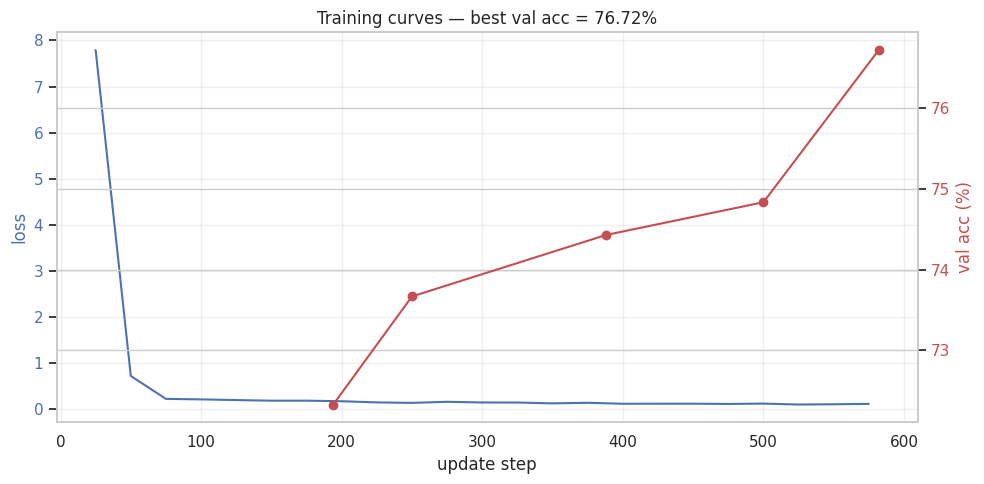

In [16]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(history["step"], history["loss"], color="#4C72B0", label="train loss")
ax1.set_xlabel("update step"); ax1.set_ylabel("loss", color="#4C72B0"); ax1.tick_params(axis='y', labelcolor="#4C72B0")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(history["eval_step"], [a*100 for a in history["eval_acc"]], color="#C44E52", marker="o", label="val acc %")
ax2.set_ylabel("val acc (%)", color="#C44E52"); ax2.tick_params(axis='y', labelcolor="#C44E52")

plt.title(f"Training curves — best val acc = {best_acc*100:.2f}%")
plt.tight_layout()
plt.savefig(cfg.out_dir / "train_curves.png", dpi=120)
plt.show()

## 14. Per-subject / grade analysis on full validation

This is the most useful diagnostic. If `social science` is at 80 % but `natural science` is at 50 %, you know exactly where to focus the next round of prompt or data tweaks.

In [17]:
# Reload the BEST adapter so this analysis reflects the saved checkpoint, not the last step
from peft import PeftModel
# (Already loaded as `model`; if you'd reset the kernel you'd reload here.)

print("Running full validation eval — this can take a few minutes …")
full_eval = evaluate(model, val_ds, max_samples=None, return_per_example=True)
print(f"FULL val acc: {full_eval['accuracy']*100:.2f}% (n={full_eval['n']})")

eval_df = pd.DataFrame({
    "id"   : full_eval["ids"],
    "pred" : full_eval["preds"],
    "gt"   : full_eval["gts"],
})
eval_df["correct"] = (eval_df["pred"] == eval_df["gt"]).astype(int)
eval_df = eval_df.merge(val_df[["id", "subject", "topic", "grade", "category"]], on="id")

print("\n— accuracy by subject —")
print(eval_df.groupby("subject")["correct"].agg(["mean", "count"]).rename(columns={"mean":"acc"}).sort_values("acc"))
print("\n— accuracy by grade —")
print(eval_df.groupby("grade")["correct"].agg(["mean", "count"]).rename(columns={"mean":"acc"}).sort_values("acc"))

# Save for reference
eval_df.to_csv(cfg.out_dir / "val_predictions.csv", index=False)
print("\nsaved:", cfg.out_dir / "val_predictions.csv")

Running full validation eval — this can take a few minutes …
FULL val acc: 76.72% (n=1048)

— accuracy by subject —
                       acc  count
subject                          
language science  0.535714     28
natural science   0.738739    777
social science    0.884774    243

— accuracy by grade —
              acc  count
grade                   
grade12  0.250000      8
grade8   0.649351    231
grade3   0.773585    106
grade6   0.802083    192
grade7   0.802198    182
grade4   0.808140    172
grade5   0.815126    119
grade2   0.888889     36
grade10  1.000000      1
grade1   1.000000      1

saved: /content/drive/MyDrive/scienceqa/outputs_train/val_predictions.csv


## 15. Save final artefacts

We've already been saving the best adapter during training. This cell just confirms it's there and writes a small `train_meta.json` so `infer.ipynb` knows what config was used.

In [18]:
meta = {
    "model_id"           : cfg.model_id,
    "img_size"           : cfg.img_size,
    "lora_r"             : cfg.lora_r,
    "lora_alpha"         : cfg.lora_alpha,
    "lora_target_modules": list(cfg.lora_target_modules),
    "best_val_acc"       : float(best_acc),
    "trainable_params"   : int(trainable),
    "max_context_chars"  : cfg.max_context_chars,
    "use_lecture"        : cfg.use_lecture,
    "use_hint"           : cfg.use_hint,
}
with open(cfg.adapter_dir / "train_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Adapter directory contents:")
for p in sorted(cfg.adapter_dir.iterdir()):
    print("  ", p.name, f"({p.stat().st_size//1024} KB)")
print(f"\n✅ done. Point infer.ipynb at: {cfg.adapter_dir.resolve()}")

Adapter directory contents:
   README.md (5 KB)
   adapter_config.json (0 KB)
   adapter_model.safetensors (16302 KB)
   added_tokens.json (4 KB)
   chat_template.jinja (0 KB)
   merges.txt (455 KB)
   preprocessor_config.json (0 KB)
   processor_config.json (0 KB)
   special_tokens_map.json (1 KB)
   tokenizer.json (3465 KB)
   tokenizer_config.json (27 KB)
   train_meta.json (0 KB)
   vocab.json (781 KB)

✅ done. Point infer.ipynb at: /content/drive/MyDrive/scienceqa/outputs_train/adapter


In [19]:
import os, gc, json, time, random, shutil, datetime
from pathlib import Path
import numpy as np
import torch
from torch.optim import AdamW

# ── 1) Mount Drive + back up the seed-42 adapter immediately ──────────────
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    print("✅ Drive mounted")
except ImportError:
    print("ℹ️  Not in Colab")

DRIVE_ROOT = Path("/content/drive/MyDrive/scienceqa_run_final_overnight")
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)

dst_a = DRIVE_ROOT / "seed42_res384"
if dst_a.exists(): shutil.rmtree(dst_a)
shutil.copytree(cfg.adapter_dir, dst_a)
(dst_a / "meta.json").write_text(json.dumps({
    "seed": 42, "img_size": cfg.img_size, "best_val_acc": float(best_acc),
    "best_step": int(best_step), "saved_at": datetime.datetime.now().isoformat(timespec="seconds"),
}, indent=2))
print(f"✅ Run A backed up to {dst_a}")

# ── 2) Free GPU memory from Run A ─────────────────────────────────────────
try:
    del model, optimizer, scheduler, trainable_params, base_model
except NameError:
    pass
gc.collect(); torch.cuda.empty_cache()
print(f"GPU free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted
✅ Run A backed up to /content/drive/MyDrive/scienceqa_run_final_overnight/seed42_res384
GPU free: 81.1 GB


In [20]:
# ── 3) Reconfigure for Run B ──────────────────────────────────────────────
SEED2 = 7
random.seed(SEED2); np.random.seed(SEED2); torch.manual_seed(SEED2); torch.cuda.manual_seed_all(SEED2)

cfg.epochs       = 3
cfg.img_size     = 512                                  # higher res for diagrams
cfg.adapter_dir  = Path("outputs_train/adapter_seed7"); cfg.adapter_dir.mkdir(parents=True, exist_ok=True)
local_drive_b    = DRIVE_ROOT / "seed7_res512"
local_drive_b.mkdir(parents=True, exist_ok=True)

# ── 4) Rebuild datasets + loader at the new resolution ────────────────────
train_ds = ScienceQADataset(train_df, cfg.data_dir, img_size=cfg.img_size,
                            is_train=True, shuffle_choices=cfg.shuffle_choices_train)
val_ds   = ScienceQADataset(val_df,   cfg.data_dir, img_size=cfg.img_size, is_train=False)
train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=cfg.micro_bsz, shuffle=True,
    collate_fn=train_collate, num_workers=0, pin_memory=True, drop_last=True,
)
print(f"Run B datasets ready (img_size={cfg.img_size})  steps/epoch={len(train_loader)}")

Run B datasets ready (img_size=512)  steps/epoch=777


In [21]:
# ── 5) Reload BASE model fresh (no carry-over from seed-42 LoRA) ──────────
from transformers import AutoModelForImageTextToText, get_cosine_schedule_with_warmup
from peft import get_peft_model
base_model = AutoModelForImageTextToText.from_pretrained(
    cfg.model_id, dtype=torch.bfloat16, device_map="auto", low_cpu_mem_usage=True,
)
for p in base_model.parameters(): p.requires_grad = False
base_model.config.use_cache = False
model = get_peft_model(base_model, lora_cfg)        # same LoRA topology as Run A
model.gradient_checkpointing_enable()
if hasattr(model, "enable_input_require_grads"): model.enable_input_require_grads()
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params (Run B): {trainable:,}")
assert trainable <= 5_000_000

Trainable params (Run B): 4,161,536


In [22]:
# ── 6) Optim + cosine schedule for Run B's horizon ────────────────────────
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(trainable_params, lr=cfg.lr, weight_decay=cfg.weight_decay)
total_update_steps = (len(train_loader) // cfg.grad_accum) * cfg.epochs
warmup_steps = max(1, int(total_update_steps * cfg.warmup_ratio))
scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_update_steps)
print(f"Run B  total_updates={total_update_steps}  warmup={warmup_steps}")

# ── 7) Helper that mirrors best adapter to Drive on every improvement ────
def _save_best(acc, step):
    global best_acc, best_step
    if acc > best_acc:
        best_acc, best_step = acc, step
        model.save_pretrained(cfg.adapter_dir)
        processor.save_pretrained(cfg.adapter_dir)
        for f in Path(cfg.adapter_dir).glob("*"):
            if f.is_file(): shutil.copy2(f, local_drive_b / f.name)
        print(f"  ★ new best ({acc*100:.2f}%) — mirrored to Drive: {local_drive_b}")

Run B  total_updates=582  warmup=29


In [23]:
# ── 8) Training loop (inlined) ────────────────────────────────────────────
history = {"step": [], "loss": [], "eval_step": [], "eval_acc": []}
best_acc, best_step = -1.0, -1
update_step = micro_step = 0
running_loss = 0.0; loss_count = 0
t0 = time.time()

for epoch in range(cfg.epochs):
    print(f"\n=== Run B (seed=7) Epoch {epoch+1}/{cfg.epochs} ===")
    model.train(); optimizer.zero_grad(set_to_none=True)
    for batch in train_loader:
        batch = {k:(v.to(model.device) if torch.is_tensor(v) else v) for k,v in batch.items()}
        out = model(**batch)
        loss = out.loss / cfg.grad_accum
        loss.backward()
        running_loss += loss.item() * cfg.grad_accum; loss_count += 1
        micro_step += 1
        if micro_step % cfg.grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(trainable_params, cfg.max_grad_norm)
            optimizer.step(); scheduler.step(); optimizer.zero_grad(set_to_none=True)
            update_step += 1
            if update_step % cfg.log_every == 0:
                avg = running_loss / max(1, loss_count); running_loss = 0.0; loss_count = 0
                history["step"].append(update_step); history["loss"].append(avg)
                print(f"  step {update_step:>5d}/{total_update_steps}  loss={avg:.4f}  "
                      f"lr={scheduler.get_last_lr()[0]:.2e}  elapsed={(time.time()-t0)/60:.1f}m")
            if update_step % cfg.eval_every == 0:
                ev = evaluate(model, val_ds, max_samples=cfg.eval_max_samples)
                history["eval_step"].append(update_step); history["eval_acc"].append(ev["accuracy"])
                print(f"  ↪ val acc (n={ev['n']}): {ev['accuracy']*100:.2f}%")
                _save_best(ev["accuracy"], update_step); model.train()
    ev = evaluate(model, val_ds, max_samples=min(len(val_ds), 1500))
    history["eval_step"].append(update_step); history["eval_acc"].append(ev["accuracy"])
    print(f"--- end epoch {epoch+1} val acc (n={ev['n']}): {ev['accuracy']*100:.2f}%")
    _save_best(ev["accuracy"], update_step)

print(f"\n✅ Run B done in {(time.time()-t0)/60:.1f} min — best val = {best_acc*100:.2f}%")


=== Run B (seed=7) Epoch 1/3 ===
  step    25/582  loss=7.7917  lr=8.62e-05  elapsed=6.8m
  step    50/582  loss=0.7352  lr=9.96e-05  elapsed=13.6m
  step    75/582  loss=0.1965  lr=9.83e-05  elapsed=20.5m
  step   100/582  loss=0.1963  lr=9.60e-05  elapsed=27.2m
  step   125/582  loss=0.1719  lr=9.27e-05  elapsed=34.1m
  step   150/582  loss=0.1484  lr=8.86e-05  elapsed=40.9m
  step   175/582  loss=0.1619  lr=8.38e-05  elapsed=47.7m
--- end epoch 1 val acc (n=1048): 73.19%
  ★ new best (73.19%) — mirrored to Drive: /content/drive/MyDrive/scienceqa_run_final_overnight/seed7_res512

=== Run B (seed=7) Epoch 2/3 ===
  step   200/582  loss=0.1622  lr=7.82e-05  elapsed=63.2m
  step   225/582  loss=0.1248  lr=7.21e-05  elapsed=70.0m
  step   250/582  loss=0.1220  lr=6.55e-05  elapsed=76.9m
  ↪ val acc (n=600): 72.67%
  step   275/582  loss=0.1388  lr=5.86e-05  elapsed=88.3m
  step   300/582  loss=0.1252  lr=5.16e-05  elapsed=95.1m
  step   325/582  loss=0.1226  lr=4.45e-05  elapsed=101.9m


In [24]:
# ── 9) Final meta + summary on Drive ──────────────────────────────────────
(local_drive_b / "meta.json").write_text(json.dumps({
    "seed": 7, "img_size": 512, "epochs": cfg.epochs,
    "best_val_acc": float(best_acc), "best_step": int(best_step),
    "trainable_params": int(trainable),
    "elapsed_min": round((time.time()-t0)/60, 1),
    "finished_at": datetime.datetime.now().isoformat(timespec="seconds"),
}, indent=2))
(local_drive_b / "history.json").write_text(json.dumps(history))

summary = {
    "run_A": str(dst_a),
    "run_B": str(local_drive_b),
    "run_B_best_val_acc": float(best_acc),
    "finished_at": datetime.datetime.now().isoformat(timespec="seconds"),
}
(DRIVE_ROOT / "OVERNIGHT_SUMMARY.json").write_text(json.dumps(summary, indent=2))
print("\n=== OVERNIGHT SUMMARY ===")
print(json.dumps(summary, indent=2))


=== OVERNIGHT SUMMARY ===
{
  "run_A": "/content/drive/MyDrive/scienceqa_run_final_overnight/seed42_res384",
  "run_B": "/content/drive/MyDrive/scienceqa_run_final_overnight/seed7_res512",
  "run_B_best_val_acc": 0.7729007633587787,
  "finished_at": "2026-05-02T09:54:08"
}


In [25]:
# ── 10) Disconnect to stop credit burn ────────────────────────────────────
print("\nSleeping 60s to flush Drive…")
time.sleep(60)
print("Disconnecting runtime. 💤")
try:
    from google.colab import runtime
    runtime.unassign()
except Exception as e:
    print("runtime.unassign failed:", e)
    os._exit(0)



Sleeping 60s to flush Drive…
Disconnecting runtime. 💤


## 16. (Optional) Diagnostic — choice-shuffle TTA preview

Before committing to TTA in `infer.ipynb`, we sanity-check that scoring is stable: predict on the validation set under two different choice orderings and see how often they agree. If TTA agreement is >95 % the model is robust; if it's lower, TTA will materially help.

In [ ]:
def predict_with_perm(model, dataset, n_samples=300, seed=0):
    rng = np.random.RandomState(seed)
    preds, mapped = [], []
    for i in range(n_samples):
        item = dataset[i]
        perm = rng.permutation(len(item["choices"]))
        shuffled = [item["choices"][k] for k in perm]
        # score on shuffled
        out = score_batch(model, [item], choices_override=[shuffled])[0]
        # map back to original index
        original_idx = int(perm[out])
        preds.append(original_idx)
    return np.array(preds)

orig = predict_with_perm(model, val_ds, n_samples=300, seed=0)
alt  = predict_with_perm(model, val_ds, n_samples=300, seed=1)
print("Perm-A vs Perm-B agreement:", round((orig == alt).mean()*100, 1), "%")
print("Perm-A acc :", round((orig == np.array([val_ds[i]['answer'] for i in range(300)])).mean()*100, 2), "%")
print("Perm-B acc :", round((alt  == np.array([val_ds[i]['answer'] for i in range(300)])).mean()*100, 2), "%")

---

## Train C


In [22]:
import os, gc, json, time, random, shutil, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.optim import AdamW

# ── 0) Free GPU memory from any leftover model ───────────────────────────
for v in ("model", "optimizer", "scheduler", "trainable_params", "base_model"):
    if v in dir(): exec(f"del {v}")
gc.collect(); torch.cuda.empty_cache()
print(f"GPU free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

GPU free: 83.4 GB


In [23]:
SEED_C = 21
random.seed(SEED_C); np.random.seed(SEED_C); torch.manual_seed(SEED_C); torch.cuda.manual_seed_all(SEED_C)

DRIVE_ROOT  = Path("/content/drive/MyDrive/scienceqa_run_final_overnight")
RUN_B_DIR   = DRIVE_ROOT / "seed7_res512"             # adapter to continue from
RUN_C_DIR   = DRIVE_ROOT / "seed21_res512_CoT"        # destination for Run C
RUN_C_DIR.mkdir(parents=True, exist_ok=True)
assert RUN_B_DIR.exists(), f"Run B adapter not found at {RUN_B_DIR}"


In [24]:
cfg.epochs       = 3
cfg.img_size     = 512
cfg.lr           = 5e-5         # low — we're continuing a converged adapter
cfg.adapter_dir  = Path("outputs_train/adapter_run_C")
cfg.adapter_dir.mkdir(parents=True, exist_ok=True)

In [25]:
val_shuffled = val_df.sample(frac=1, random_state=SEED_C).reset_index(drop=True)
N_MONITOR    = 420
val_monitor  = val_shuffled.iloc[:N_MONITOR].reset_index(drop=True)
val_train    = val_shuffled.iloc[N_MONITOR:].reset_index(drop=True)
combined_train = pd.concat([train_df, val_train], ignore_index=True)
print(f"Combined train: {len(combined_train):,}  (train={len(train_df)} + val_train={len(val_train)})")
print(f"Monitor val   : {len(val_monitor):,}")

Combined train: 3,737  (train=3109 + val_train=628)
Monitor val   : 420


In [31]:
# ── 4) CoT-aware message builder + collator (override the originals) ─────
def build_messages_cot(row, choices, *, include_answer, answer_idx,
                       max_ctx, use_lecture, use_hint):
    user_text = build_user_text(row, max_ctx=max_ctx,
                                 use_lecture=use_lecture, use_hint=use_hint,
                                 choices=choices)
    msgs = [{"role":"user","content":[{"type":"image"},{"type":"text","text":user_text}]}]
    if include_answer:
        letter = CHOICE_LETTERS[answer_idx]
        sol = row.get("solution", None)
        if isinstance(sol, str) and sol.strip():
            sol_short = sol.strip()[:400]
            assistant_text = f"{letter}. {sol_short}"
        else:
            assistant_text = letter
        msgs.append({"role":"assistant","content":[{"type":"text","text":assistant_text}]})
    return msgs

def make_train_batch_cot(items):
    """Like make_train_batch, but uses CoT assistant turn (letter + solution)."""
    images, full_texts, prompt_texts = [], [], []
    for it in items:
        msgs_full = build_messages_cot(
            it["row"], it["choices"], include_answer=True, answer_idx=it["answer"],
            max_ctx=cfg.max_context_chars, use_lecture=cfg.use_lecture, use_hint=cfg.use_hint,
        )
        msgs_prompt = build_messages_cot(
            it["row"], it["choices"], include_answer=False, answer_idx=0,
            max_ctx=cfg.max_context_chars, use_lecture=cfg.use_lecture, use_hint=cfg.use_hint,
        )
        full_texts.append(processor.apply_chat_template(msgs_full, add_generation_prompt=False))
        prompt_texts.append(processor.apply_chat_template(msgs_prompt, add_generation_prompt=True))
        images.append([it["image"]])

    processor.tokenizer.padding_side = "right"
    enc = processor(text=full_texts, images=images, return_tensors="pt", padding=True)
    plens = []
    for p, im in zip(prompt_texts, images):
        pe = processor(text=p, images=im, return_tensors="pt")
        plens.append(int(pe["input_ids"].shape[1]))
    labels = enc["input_ids"].clone()
    for i, pl in enumerate(plens): labels[i, :pl] = -100
    labels[enc["attention_mask"] == 0] = -100
    enc["labels"] = labels
    processor.tokenizer.padding_side = "left"
    return enc

train_ds = ScienceQADataset(combined_train, cfg.data_dir, img_size=cfg.img_size,
                            is_train=True, shuffle_choices=cfg.shuffle_choices_train)
val_ds   = ScienceQADataset(val_monitor,   cfg.data_dir, img_size=cfg.img_size, is_train=False)
train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=cfg.micro_bsz, shuffle=True,
    collate_fn=make_train_batch_cot, num_workers=0, pin_memory=True, drop_last=True,
)
print(f"steps/epoch={len(train_loader)}  effective_batch={cfg.micro_bsz*cfg.grad_accum}")


steps/epoch=934  effective_batch=16


In [32]:
# ── 5) Reload base + Run B adapter (trainable) ───────────────────────────
from transformers import AutoModelForImageTextToText, get_cosine_schedule_with_warmup
from peft import PeftModel
base_model = AutoModelForImageTextToText.from_pretrained(
    cfg.model_id, dtype=torch.bfloat16, device_map="auto", low_cpu_mem_usage=True,
)
for p in base_model.parameters(): p.requires_grad = False
base_model.config.use_cache = False
model = PeftModel.from_pretrained(base_model, str(RUN_B_DIR), is_trainable=True)
model.gradient_checkpointing_enable()
if hasattr(model, "enable_input_require_grads"): model.enable_input_require_grads()
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,} (continuing from Run B)")
assert trainable <= 5_000_000

Trainable params: 4,161,536 (continuing from Run B)


In [33]:
# ── 6) Optim + cosine schedule ───────────────────────────────────────────
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(trainable_params, lr=cfg.lr, weight_decay=cfg.weight_decay)
total_update_steps = (len(train_loader) // cfg.grad_accum) * cfg.epochs
warmup_steps = max(1, int(total_update_steps * cfg.warmup_ratio))
scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_update_steps)
print(f"total_updates={total_update_steps}  warmup={warmup_steps}  lr={cfg.lr}")


total_updates=699  warmup=34  lr=5e-05


In [34]:
# ── 7) Best-mirror save helper ───────────────────────────────────────────
def _save_best_c(acc, step):
    global best_acc, best_step
    if acc > best_acc:
        best_acc, best_step = acc, step
        model.save_pretrained(cfg.adapter_dir)
        processor.save_pretrained(cfg.adapter_dir)
        for f in Path(cfg.adapter_dir).glob("*"):
            if f.is_file(): shutil.copy2(f, RUN_C_DIR / f.name)
        print(f"  ★ new best ({acc*100:.2f}%) — mirrored to Drive: {RUN_C_DIR}")


In [35]:
# ── 8) Train ─────────────────────────────────────────────────────────────
history = {"step":[], "loss":[], "eval_step":[], "eval_acc":[]}
best_acc, best_step = -1.0, -1
update_step = micro_step = 0
running_loss = 0.0; loss_count = 0
t0 = time.time()

for epoch in range(cfg.epochs):
    print(f"\n=== Phase 2 CoT  Epoch {epoch+1}/{cfg.epochs} ===")
    model.train(); optimizer.zero_grad(set_to_none=True)
    for batch in train_loader:
        batch = {k:(v.to(model.device) if torch.is_tensor(v) else v) for k,v in batch.items()}
        out = model(**batch)
        loss = out.loss / cfg.grad_accum
        loss.backward()
        running_loss += loss.item() * cfg.grad_accum; loss_count += 1
        micro_step += 1
        if micro_step % cfg.grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(trainable_params, cfg.max_grad_norm)
            optimizer.step(); scheduler.step(); optimizer.zero_grad(set_to_none=True)
            update_step += 1
            if update_step % cfg.log_every == 0:
                avg = running_loss / max(1, loss_count); running_loss = 0.0; loss_count = 0
                history["step"].append(update_step); history["loss"].append(avg)
                print(f"  step {update_step:>5d}/{total_update_steps}  loss={avg:.4f}  "
                      f"lr={scheduler.get_last_lr()[0]:.2e}  elapsed={(time.time()-t0)/60:.1f}m")
            if update_step % cfg.eval_every == 0:
                ev = evaluate(model, val_ds, max_samples=None)   # full monitor set (n=420)
                history["eval_step"].append(update_step); history["eval_acc"].append(ev["accuracy"])
                print(f"  ↪ monitor acc (n={ev['n']}): {ev['accuracy']*100:.2f}%")
                _save_best_c(ev["accuracy"], update_step); model.train()
    ev = evaluate(model, val_ds, max_samples=None)
    history["eval_step"].append(update_step); history["eval_acc"].append(ev["accuracy"])
    print(f"--- end epoch {epoch+1} monitor acc (n={ev['n']}): {ev['accuracy']*100:.2f}%")
    _save_best_c(ev["accuracy"], update_step)

print(f"\n✅ Phase 2 CoT done in {(time.time()-t0)/60:.1f} min — best monitor acc = {best_acc*100:.2f}%")



=== Phase 2 CoT  Epoch 1/3 ===
  step    25/699  loss=2.0813  lr=3.68e-05  elapsed=7.0m
  step    50/699  loss=1.5062  lr=4.99e-05  elapsed=13.8m
  step    75/699  loss=1.3331  lr=4.95e-05  elapsed=20.7m
  step   100/699  loss=1.2345  lr=4.88e-05  elapsed=27.5m
  step   125/699  loss=1.1998  lr=4.77e-05  elapsed=34.5m
  step   150/699  loss=1.0799  lr=4.63e-05  elapsed=41.4m
  step   175/699  loss=0.9690  lr=4.47e-05  elapsed=48.2m
  step   200/699  loss=0.8727  lr=4.27e-05  elapsed=55.1m
  step   225/699  loss=0.8280  lr=4.05e-05  elapsed=61.8m
--- end epoch 1 monitor acc (n=420): 68.81%
  ★ new best (68.81%) — mirrored to Drive: /content/drive/MyDrive/scienceqa_run_final_overnight/seed21_res512_CoT

=== Phase 2 CoT  Epoch 2/3 ===
  step   250/699  loss=0.7824  lr=3.81e-05  elapsed=72.2m
  ↪ monitor acc (n=420): 70.71%
  ★ new best (70.71%) — mirrored to Drive: /content/drive/MyDrive/scienceqa_run_final_overnight/seed21_res512_CoT
  step   275/699  loss=0.7081  lr=3.55e-05  elapsed=8

In [36]:
# ── 9) Save meta + history to Drive ──────────────────────────────────────
(RUN_C_DIR / "meta.json").write_text(json.dumps({
    "phase": "2_CoT",
    "started_from": str(RUN_B_DIR),
    "seed": SEED_C, "img_size": cfg.img_size, "epochs": cfg.epochs, "lr": cfg.lr,
    "best_monitor_acc": float(best_acc), "best_step": int(best_step),
    "trainable_params": int(trainable),
    "elapsed_min": round((time.time()-t0)/60, 1),
    "finished_at": datetime.datetime.now().isoformat(timespec="seconds"),
    "training_data": {
        "n_train_orig": int(len(train_df)),
        "n_val_added":  int(len(val_train)),
        "monitor_n":    int(len(val_monitor)),
    },
}, indent=2))
(RUN_C_DIR / "history.json").write_text(json.dumps(history))
print(f"saved meta + history to {RUN_C_DIR}")


saved meta + history to /content/drive/MyDrive/scienceqa_run_final_overnight/seed21_res512_CoT


In [37]:
# ── 10) Disconnect runtime ───────────────────────────────────────────────
print("Sleeping 60s to flush Drive…")
time.sleep(60)
try:
    from google.colab import runtime
    runtime.unassign()
except Exception as e:
    print("runtime.unassign failed:", e); os._exit(0)


Sleeping 60s to flush Drive…
